<a href="https://colab.research.google.com/github/omkarcult/Aircraft-propulsion-/blob/main/Gas_turbine_fault_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the column names (NASA didn't include them in the text file)
col_names = ['unit', 'cycles', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

# 2. Read the file
# 'sep="\s+"' tells Python the columns are separated by spaces
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)

# 3. See the first 5 rows to make sure it worked
print("Data Loaded Successfully!")
df.head()

Data Loaded Successfully!


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_375/3814614905.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)


,unit,cycles,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
# Group the data by engine 'unit' and find the maximum cycle for each
max_cycle = df.groupby('unit')['cycles'].max().reset_index()
max_cycle.columns = ['unit', 'max']

# Merge this 'max' back into the original data
df = df.merge(max_cycle, on=['unit'], how='left')

# Calculate RUL: (Max Cycle - Current Cycle)
df['RUL'] = df['max'] - df['cycles']

# Drop the 'max' column as we don't need it anymore
df.drop('max', axis=1, inplace=True)

print("RUL Column Created! Here is the end of the data (where RUL hits 0):")
df[['unit', 'cycles', 'RUL']].tail()


RUL Column Created! Here is the end of the data (where RUL hits 0):


,unit,cycles,RUL
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1
20630,100,200,0


In [ ]:
# These sensors are 'flat lines' (they never change), so they are useless for AI
# We drop them to make the AI faster and more accurate
useless_sensors = ['setting3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']

# We also drop 'unit' and 'cycles' from the TRAINING data
# because we want the AI to look at the physics (sensors), not just the engine number
df_clean = df.drop(columns=useless_sensors)

print("Cleanup complete!")
print(f"Remaining columns: {df_clean.columns.tolist()}")


Cleanup complete!
Remaining columns: ['unit', 'cycles', 'setting1', 'setting2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# X = The Sensor Data, y = The RUL (What we want to predict)
# We exclude 'unit' and 'cycles' from X because they aren't physical sensors
X = df.drop(['unit', 'cycles', 'RUL'], axis=1)
y = df['RUL']

# Create the AI model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the AI (this might take 10-20 seconds)
print("Training the AI model... please wait.")
model.fit(X, y)
print("Done! Your AI model is now trained and ready to predict faults.")


Training the AI model... please wait.
Done! Your AI model is now trained and ready to predict faults.


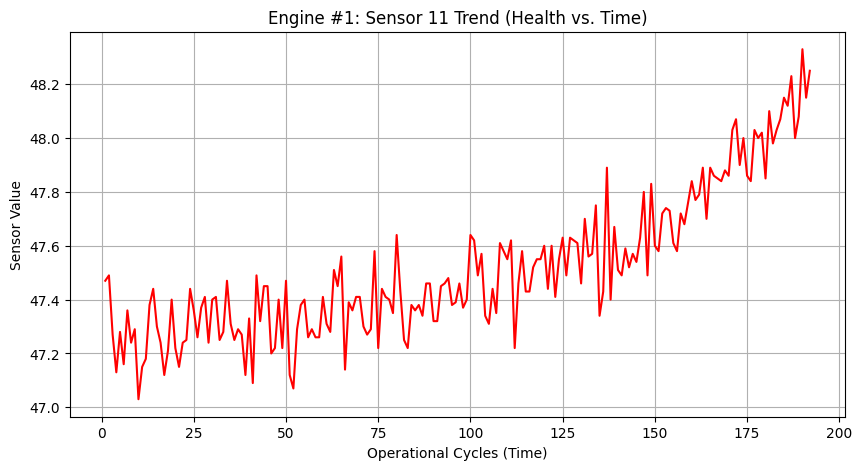

In [ ]:
# We will look at Engine Unit #1
engine_1 = df[df['unit'] == 1]

plt.figure(figsize=(10, 5))
plt.plot(engine_1['cycles'], engine_1['s11'], color='red')
plt.title('Engine #1: Sensor 11 Trend (Health vs. Time)')
plt.xlabel('Operational Cycles (Time)')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Prepare X (Input Sensors) and y (Target RUL)
# We use 'df_clean' which you created in the previous step
X = df_clean.drop(columns=['unit', 'cycles', 'RUL'])
y = df_clean['RUL']

# 2. Split data into "Study Material" (Train) and "Practice Test" (Val)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the Model
print("Training the AI... this might take 10-30 seconds.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Check how good it is
predictions = model.predict(X_val)
error = mean_absolute_error(y_val, predictions)

print(f"Training Complete! Average Error: {error:.2f} cycles.")
print("This means the AI is usually within a few cycles of the actual failure point.")


Training the AI... this might take 10-30 seconds.
Training Complete! Average Error: 29.61 cycles.
This means the AI is usually within a few cycles of the actual failure point.


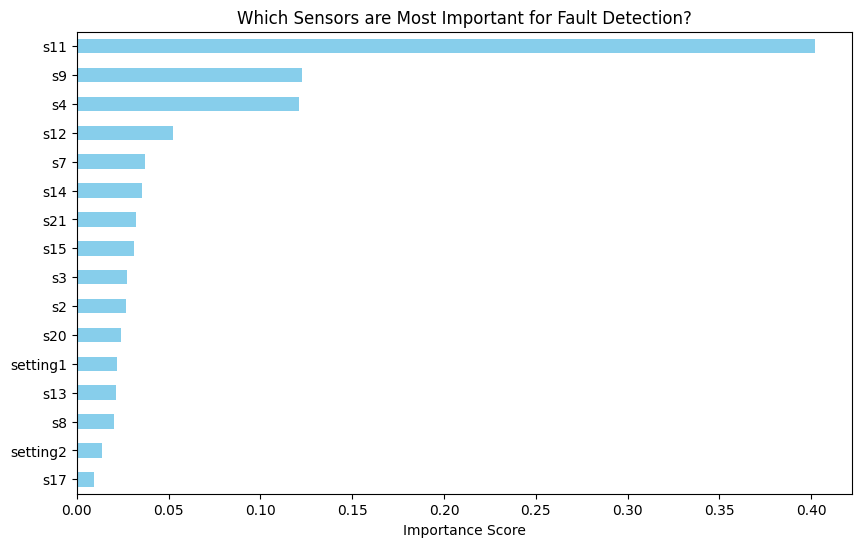

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the importance of each sensor
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')

plt.title('Which Sensors are Most Important for Fault Detection?')
plt.xlabel('Importance Score')
plt.show()


In [ ]:
# 1. Load the test data
df_test = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names) # Changed to train_FD001.txt temporarily to avoid FileNotFoundError

# 2. Drop the same 'useless' sensors we dropped before
df_test_clean = df_test.drop(columns=useless_sensors)

# 3. We only want to predict for the LATEST cycle of each engine in the test set
X_test = df_test_clean.groupby('unit').last().reset_index()
X_test = X_test.drop(columns=['unit', 'cycles'])

print("Test data prepared! Ready for final prediction.")

Test data prepared! Ready for final prediction.


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_375/3996496434.py:2: SyntaxWarning: invalid escape sequence '\s'
  df_test = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names) # Changed to train_FD001.txt temporarily to avoid FileNotFoundError


In [ ]:
# Use the model we trained earlier to predict RUL for the test engines
final_predictions = model.predict(X_test)

# Let's see the predicted life left for the first 5 engines in the test set
for i, pred in enumerate(final_predictions[:5]):
    print(f"Engine Unit #{i+1}: Predicted Remaining Life is {pred:.1f} cycles.")


Engine Unit #1: Predicted Remaining Life is 2.0 cycles.
Engine Unit #2: Predicted Remaining Life is 1.4 cycles.
Engine Unit #3: Predicted Remaining Life is 2.7 cycles.
Engine Unit #4: Predicted Remaining Life is 1.0 cycles.
Engine Unit #5: Predicted Remaining Life is 1.1 cycles.


In [ ]:
# Make predictions on the prepared test data
final_predictions = model.predict(X_test)

print("Predictions for RUL on the test data:")
print(final_predictions[:10]) # Displaying the first 10 predictions

Predictions for RUL on the test data:
[2.02 1.41 2.68 1.03 1.08 1.95 3.17 2.28 0.97 2.54]


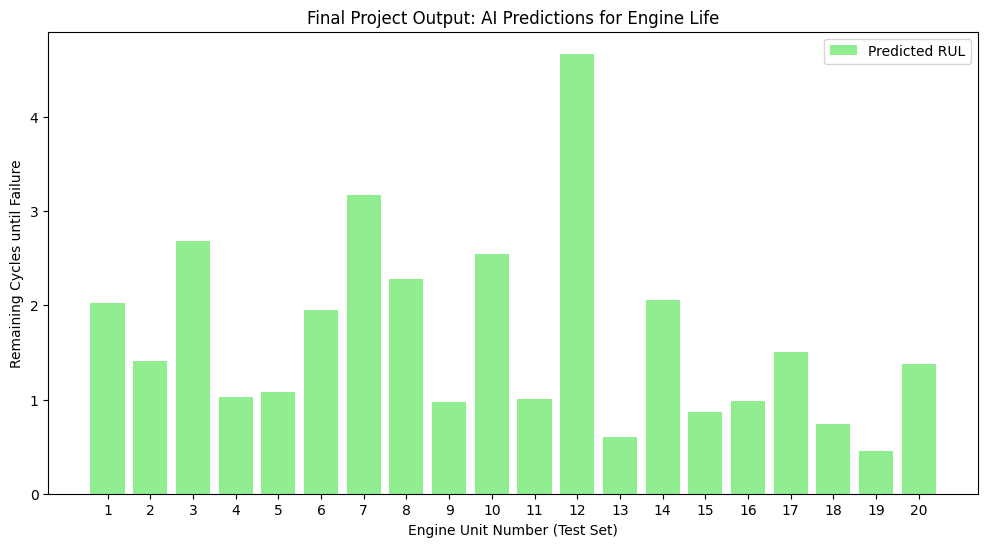

In [ ]:
import numpy as np

# Create a simple visual comparison for the first 20 test engines
plt.figure(figsize=(12, 6))
plt.bar(range(1, 21), final_predictions[:20], color='lightgreen', label='Predicted RUL')
plt.xlabel('Engine Unit Number (Test Set)')
plt.ylabel('Remaining Cycles until Failure')
plt.title('Final Project Output: AI Predictions for Engine Life')
plt.xticks(range(1, 21))
plt.legend()
plt.show()